# MUFASA metadata classification

This notebook:

1. tests one model on 10 gold papers;
2. benchmarks it on the confirmed 200-paper gold set;
3. after model selection, runs the citation-first workflow until exactly 6,000 papers are selected.

The model sees only the rubric, title, abstract, OpenAlex field/topic, and a few keywords. It never receives `gold_*` columns, MUFASA category codes, affiliations, licences, or download fields.

Run the notebook once for each model by changing `MODEL_CHOICE`. Do not enable the production cell until the benchmark comparison is complete.

## 1. Install the small set of notebook dependencies

In [1]:
pip install google-cloud-bigquery-storage>=2.0.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Kaggle already provides the remaining packages.
%pip install -q -U "transformers>=5.0.0,<6" accelerate huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 96.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 98.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 30.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## 2. Configuration

In [3]:
from pathlib import Path

# Change only these paths to match the Kaggle datasets you attach.
GOLD_PARQUET = Path("/kaggle/input/mufasa-data/classification_benchmark_200.parquet")
# RAW_CSV = Path("/kaggle/input/mufasa-data/openalex_all_fields.csv")
SLIM_PARQUET = Path("/kaggle/input/mufasa-data/openalex_candidates_slim.parquet")
WORKING_SLIM_PARQUET = Path("/kaggle/working/openalex_candidates_slim.parquet")
OUTPUT_ROOT = Path("/kaggle/working/mufasa_classification")

# Run the notebook once with each choice: qwen2b, qwen4b, bonsai27b.
MODEL_CHOICE = "bonsai27b"
MODEL_IDS = {
    "qwen2b": "Qwen/Qwen3.5-2B",
    "qwen4b": "Qwen/Qwen3.5-4B",
    "bonsai27b": "prism-ml/Bonsai-27B-gguf",
}

BATCH_SIZE = 4
MAX_INPUT_TOKENS = 4000
MAX_PROMPT_CHARS = 18000
MAX_OUTPUT_TOKENS = 1024
CHECKPOINT_EVERY = 1000
TARGET_PER_FIELD = 300
TARGET_TOTAL = 6_000

# --- llama-server context budget -------------------------------------------
# llama-server divides -c across --parallel slots. With -c 1024 --parallel 4
# every request gets 256 tokens, which silently truncates a ~1,400-token
# prompt and makes every call fail. Always size the slot, then multiply.
SERVER_PARALLEL = BATCH_SIZE
CTX_PER_SLOT = 4096                              # prompt (~1,400) + output
SERVER_CTX = CTX_PER_SLOT * SERVER_PARALLEL      # what -c actually receives

assert CTX_PER_SLOT >= MAX_OUTPUT_TOKENS + 2048, (
    "Each slot must hold the prompt and the full response"
)

# Sampling values from the official Bonsai 27B launcher
# (Bonsai-demo/scripts/start_llama_server.sh). Bonsai 27B is a reasoning
# model, so thinking is NOT disabled for it; the seed keeps runs comparable.
BONSAI_SAMPLING = {
    "temperature": 0.7,
    "top_p": 0.95,
    "top_k": 20,
    "min_p": 0,
    "seed": 42,
}

# Leave False during smoke tests and model benchmarking.
RUN_PRODUCTION = False

assert MODEL_CHOICE in MODEL_IDS
MODEL_ID = MODEL_IDS[MODEL_CHOICE]
MODEL_OUTPUT_DIR = OUTPUT_ROOT / MODEL_CHOICE
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Model:", MODEL_ID)
print("Outputs:", MODEL_OUTPUT_DIR)
print(f"Server context: {SERVER_CTX} total = {CTX_PER_SLOT} x {SERVER_PARALLEL} slots")

Model: prism-ml/Bonsai-27B-gguf
Outputs: /kaggle/working/mufasa_classification/bonsai27b
Server context: 16384 total = 4096 x 4 slots


In [4]:
1+1

2

## 3. Imports, rubric, and prompt construction

In [5]:
from __future__ import annotations

import concurrent.futures
import hashlib
import html
import json
import math
import re
import subprocess
import time

import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

from collections import defaultdict
from dataclasses import dataclass
from datetime import datetime, timezone
from typing import Any, Iterable

import pandas as pd
import requests
import warnings
warnings.filterwarnings('ignore')

PROMPT_VERSION = "mufasa_relevance_v1"
RUBRIC_VERSION = "mufasa_rubric_v1"
SCORE_NAMES = (
    "african_centrality",
    "local_specificity",
    "scientific_depth",
    "knowledge_value",
    "local_applicability",
)

# No taxonomy or category codes are included here.
RUBRIC_PROMPT = '''You screen scientific papers for MUFASA.
Decide whether the scientific contribution is materially connected to Africa. African authorship, affiliation, venue, or an incidental study location alone is insufficient.
Include when African materials, resources, crops, organisms, populations, environments, datasets, operating conditions, local methods, or technical constraints materially affect the question, evidence, interpretation, or application.
Exclude generic work and non-scientific, social-science, business, legal, humanities, or education-only work. Use review when metadata is insufficient or genuinely ambiguous.
Score 0-4: african_centrality, local_specificity, scientific_depth, knowledge_value, local_applicability.
Include requires total >=14, african_centrality >=2, scientific_depth >=2, and no hard exclusion.
Return one minified JSON object only:
{"decision":"include|review|exclude","hard_exclusion":false,"african_centrality":0,"local_specificity":0,"scientific_depth":0,"knowledge_value":0,"local_applicability":0,"evidence":"exact title/abstract excerpt, at most 20 words","reason":"at most 30 words"}
Use only the supplied metadata. Prefer review over an unsupported exclusion.'''

FORBIDDEN_PROMPT_MARKERS = (
    "gold_",
    "category_codes",
    "MAT-BLD-",
    "AGR-CRO-",
    "HLT-INF-",
    "ENR-PET-",
    "ENV-WAT-",
    "TEC-GEO-",
)


def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat(timespec="seconds")


def clean_text(value: Any, limit: int | None = None) -> str:
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return ""
    text = html.unescape(str(value))
    text = re.sub(r"\s+", " ", text).strip()
    return text[:limit] if limit else text


def csv_encoding(path: Path) -> str:
    sample = path.read_bytes()[:131_072]
    try:
        sample.decode("utf-8-sig")
        return "utf-8-sig"
    except UnicodeDecodeError:
        return "cp1252"


def read_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() in {".parquet", ".pq"}:
        return pd.read_parquet(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(
            path,
            encoding=csv_encoding(path),
            encoding_errors="replace",
            low_memory=False,
        )
    raise ValueError(f"Expected CSV or Parquet, received: {path}")


def as_bool(value: Any) -> bool:
    if isinstance(value, bool):
        return value
    return str(value).strip().lower() in {"1", "true", "yes", "y"}


def scalar_json(value: Any) -> Any:
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return None
    if hasattr(value, "item"):
        return value.item()
    if isinstance(value, pd.Timestamp):
        return value.isoformat()
    return value


def row_dict(row: pd.Series) -> dict[str, Any]:
    return {str(key): scalar_json(value) for key, value in row.items()}


def extract_keywords(value: Any, maximum: int = 5) -> str:
    text = clean_text(value)
    if not text:
        return ""
    try:
        payload = json.loads(text)
    except json.JSONDecodeError:
        return clean_text(text, 160)
    values = []
    if isinstance(payload, list):
        for item in payload:
            if isinstance(item, str):
                candidate = item
            elif isinstance(item, dict):
                candidate = (
                    item.get("display_name")
                    or item.get("name")
                    or item.get("keyword")
                    or ""
                )
            else:
                candidate = ""
            candidate = clean_text(candidate, 50)
            if candidate and candidate not in values:
                values.append(candidate)
            if len(values) == maximum:
                break
    return clean_text("; ".join(values), 180)


def build_prompt(
    row: pd.Series | dict[str, Any],
    max_chars: int = MAX_PROMPT_CHARS,
    repair: bool = False,
) -> str:
    getter = row.get
    title = clean_text(getter("title", ""), 300)
    field = clean_text(
        getter("field_name", "") or getter("primary_field", ""), 100
    )
    topic = clean_text(getter("primary_topic", ""), 140)
    keywords = extract_keywords(
        getter("keywords", "") or getter("keywords_json", "")
    )
    abstract = clean_text(getter("abstract", ""))
    repair_line = (
        "\nYour previous response was invalid. Return JSON only." if repair else ""
    )
    metadata = (
        f"\nPAPER\nTitle: {title}\n"
        f"OpenAlex field: {field}\n"
        f"OpenAlex topic: {topic}\n"
        f"Keywords: {keywords}\n"
        "Abstract: "
    )
    fixed = RUBRIC_PROMPT + repair_line + metadata
    prompt = fixed[:max_chars] if len(fixed) >= max_chars else (
        fixed + abstract[: max_chars - len(fixed)]
    )
    if any(marker in prompt for marker in FORBIDDEN_PROMPT_MARKERS):
        raise AssertionError("A gold label or category code entered the prompt")
    return prompt


def prompt_hash(prompt: str) -> str:
    return hashlib.sha256(prompt.encode("utf-8")).hexdigest()

In [6]:
import os  # used by the server launcher to pass LD_LIBRARY_PATH explicitly

## 4. Optional one-time conversion of the raw OpenAlex CSV

The prepared Kaggle input already has only 11 columns. It keeps DOI and institution names, compacts keywords to five names, caps abstracts at 1,800 characters, and removes download/URL/license/full-JSON columns. Run the next cell only when rebuilding it from the original CSV.

## 5. Model backends

In [7]:
@dataclass
class Generation:
    text: str = ""
    prompt_tokens: int | None = None
    output_tokens: int | None = None
    latency_seconds: float = 0.0
    error: str = ""


class QwenBackend:
    def __init__(self, model_id: str):
        import torch
        from transformers import AutoModelForMultimodalLM, AutoProcessor

        self.torch = torch
        self.model_id = model_id
        self.processor = AutoProcessor.from_pretrained(model_id)
        self.tokenizer = self.processor.tokenizer
        self.tokenizer.padding_side = "left"
        if self.tokenizer.pad_token_id is None:
            self.tokenizer.pad_token_id = self.tokenizer.eos_token_id
        self.model = AutoModelForMultimodalLM.from_pretrained(
            model_id,
            torch_dtype=torch.float16,
            device_map="auto",
            low_cpu_mem_usage=True,
        )
        self.model.eval()

    def generate_many(self, prompts: list[str]) -> list[Generation]:
        chat_texts = [
            self.processor.apply_chat_template(
                [{"role": "user", "content": [{"type": "text", "text": prompt}]}],
                add_generation_prompt=True,
                tokenize=False,
                enable_thinking=False,
            )
            for prompt in prompts
        ]
        encoded = self.tokenizer(
            chat_texts,
            padding=True,
            truncation=True,
            max_length=MAX_INPUT_TOKENS,
            return_tensors="pt",
        ).to(self.model.device)
        started = time.perf_counter()
        with self.torch.inference_mode():
            generated = self.model.generate(
                **encoded,
                do_sample=False,
                max_new_tokens=MAX_OUTPUT_TOKENS,
                pad_token_id=self.tokenizer.pad_token_id,
            )
        elapsed = time.perf_counter() - started
        new_tokens = generated[:, encoded["input_ids"].shape[1] :]
        texts = self.tokenizer.batch_decode(new_tokens, skip_special_tokens=True)
        prompt_counts = encoded["attention_mask"].sum(dim=1).tolist()
        output_counts = (new_tokens != self.tokenizer.pad_token_id).sum(dim=1).tolist()
        return [
            Generation(
                text=text,
                prompt_tokens=int(prompt_count),
                output_tokens=int(output_count),
                latency_seconds=elapsed / len(prompts),
            )
            for text, prompt_count, output_count in zip(
                texts, prompt_counts, output_counts, strict=True
            )
        ]


BONSAI_REPO = Path("/kaggle/working/llama.cpp")
BONSAI_MODEL_PATH = Path("/kaggle/working/Bonsai-27B-Q1_0.gguf")
BONSAI_PORT = 8080
BONSAI_BIN_DIR = Path("/kaggle/working/Bonsai-demo/bin/cuda")
BONSAI_SERVER_LOG = Path("/kaggle/working/bonsai_server.log")


def start_bonsai_server():
    from huggingface_hub import hf_hub_download

    if not BONSAI_REPO.exists():
        subprocess.run(
            [
                "git", "clone", "--depth", "1",
                "https://github.com/PrismML-Eng/llama.cpp",
                str(BONSAI_REPO),
            ],
            check=True,
        )
    server_binary = BONSAI_REPO / "build/bin/llama-server"
    if not server_binary.exists():
        subprocess.run(
            ["cmake", "-B", str(BONSAI_REPO / "build"), "-DGGML_CUDA=ON"],
            cwd=BONSAI_REPO,
            check=True,
        )
        subprocess.run(
            ["cmake", "--build", str(BONSAI_REPO / "build"), "-j", "2"],
            cwd=BONSAI_REPO,
            check=True,
        )
    if not BONSAI_MODEL_PATH.exists():
        downloaded = hf_hub_download(
            repo_id="prism-ml/Bonsai-27B-gguf",
            filename="Bonsai-27B-Q1_0.gguf",
            local_dir="/kaggle/working",
        )
        assert Path(downloaded).exists()

    # Release binaries arrive from a zip without the execute bit or the
    # SONAME symlinks. Restore both, or the server cannot start.
    bin_dir = server_binary.parent.resolve()
    for path in bin_dir.iterdir():
        if path.is_file():
            path.chmod(path.stat().st_mode | 0o111)
    for path in list(bin_dir.glob("*.so.*")):
        match = re.match(r"^(.*\.so)\.(\d+)", path.name)
        if not match:
            continue
        for link_name in (f"{match.group(1)}.{match.group(2)}", match.group(1)):
            link = bin_dir / link_name
            if not link.exists():
                link.symlink_to(path.name)

    # -fa on / --jinja / sampling come from the official 27B launcher
    # (Bonsai-demo/scripts/start_llama_server.sh).
    #
    # Reasoning is deliberately DISABLED, which the interactive launcher does
    # not do. Bonsai 27B is a reasoning model, and left enabled it spends the
    # whole output budget thinking and returns empty `content` with
    # finish_reason=length. This is a rubric screen over thousands of papers,
    # not a chat session: chain-of-thought adds minutes per paper and no
    # accuracy we can use.
    #
    # -c is the TOTAL context; llama-server divides it across --parallel
    # slots, so it is computed from CTX_PER_SLOT rather than hard-coded.
    command = [
        str(server_binary),
        "-m", str(BONSAI_MODEL_PATH),
        "--host", "127.0.0.1",
        "--port", str(BONSAI_PORT),
        "-ngl", "99",
        "-fa", "on",
        "--jinja",
        "-c", str(SERVER_CTX),
        "--parallel", str(SERVER_PARALLEL),
        "--reasoning-budget", "0",
        "--reasoning-format", "none",
        "--temp", str(BONSAI_SAMPLING["temperature"]),
        "--top-p", str(BONSAI_SAMPLING["top_p"]),
        "--top-k", str(BONSAI_SAMPLING["top_k"]),
        "--min-p", str(BONSAI_SAMPLING["min_p"]),
    ]
    print("Launching:", " ".join(command))

    env = {
        **os.environ,
        "LD_LIBRARY_PATH": f"{BONSAI_BIN_DIR}:{os.environ.get('LD_LIBRARY_PATH', '')}",
    }
    log_handle = open(BONSAI_SERVER_LOG, "w", encoding="utf-8")
    process = subprocess.Popen(
        command,
        stdout=log_handle,
        stderr=subprocess.STDOUT,
        env=env,
    )
    health_url = f"http://127.0.0.1:{BONSAI_PORT}/health"
    for _ in tqdm(
        range(180),
        desc="Starting Bonsai server",
        unit="check",
    ):
        if process.poll() is not None:
            print(BONSAI_SERVER_LOG.read_text(encoding="utf-8", errors="replace")[-3000:])
            raise RuntimeError("Bonsai server stopped; see the log above")
        try:
            if requests.get(health_url, timeout=2).status_code == 200:
                print("Bonsai server is ready")
                return process
        except requests.RequestException:
            pass
        time.sleep(2)
    raise TimeoutError("Bonsai server did not become ready")


class BonsaiBackend:
    def __init__(self, port: int = BONSAI_PORT):
        self.model_id = "prism-ml/Bonsai-27B-gguf"
        self.url = f"http://127.0.0.1:{port}/v1/chat/completions"

    def generate_one(self, prompt: str) -> Generation:
        started = time.perf_counter()
        last_error = ""
        base = {
            "model": self.model_id,
            "messages": [{"role": "user", "content": prompt}],
            "max_tokens": MAX_OUTPUT_TOKENS,
            # Belt and braces with the server's --reasoning-budget 0.
            "chat_template_kwargs": {"enable_thinking": False},
            **BONSAI_SAMPLING,
        }
        # First ask for guaranteed JSON; fall back if the build rejects it.
        for use_json_mode in (True, False):
            payload = dict(base)
            if use_json_mode:
                payload["response_format"] = {"type": "json_object"}
            try:
                response = requests.post(self.url, json=payload, timeout=300)
                if response.status_code >= 400:
                    last_error = f"HTTP {response.status_code}: {response.text[:300]}"
                    continue
                body = response.json()
                usage = body.get("usage") or {}
                prompt_tokens = usage.get("prompt_tokens")
                if prompt_tokens is not None and prompt_tokens > MAX_INPUT_TOKENS:
                    raise ValueError(
                        f"Prompt used {prompt_tokens} tokens; limit is {MAX_INPUT_TOKENS}"
                    )
                choice = body["choices"][0]
                message = choice.get("message") or {}
                text = message.get("content") or ""
                # If reasoning still leaked through, the JSON may be sitting in
                # reasoning_content instead. Use it rather than losing the row.
                if not text.strip():
                    text = message.get("reasoning_content") or ""
                if not text.strip():
                    last_error = (
                        "Empty completion "
                        f"(finish_reason={choice.get('finish_reason')}, "
                        f"prompt_tokens={prompt_tokens}, "
                        f"completion_tokens={usage.get('completion_tokens')}). "
                        "If finish_reason is 'length', the model is still "
                        "reasoning: check --reasoning-budget 0 took effect."
                    )
                    continue
                return Generation(
                    text=text,
                    prompt_tokens=prompt_tokens,
                    output_tokens=usage.get("completion_tokens"),
                    latency_seconds=time.perf_counter() - started,
                )
            except Exception as exc:
                last_error = f"{type(exc).__name__}: {exc}"
        return Generation(
            latency_seconds=time.perf_counter() - started,
            error=last_error or "Unknown Bonsai server error",
        )

    def generate_many(self, prompts: list[str]) -> list[Generation]:
        with concurrent.futures.ThreadPoolExecutor(
            max_workers=min(BATCH_SIZE, len(prompts))
        ) as pool:
            return list(pool.map(self.generate_one, prompts))

## 6. Output validation and classification

In [8]:
def strip_to_json(text: str) -> str:
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)
    text = text.replace("```json", "").replace("```", "").strip()
    start, end = text.find("{"), text.rfind("}")
    if start < 0 or end < start:
        raise ValueError("No JSON object found")
    return text[start : end + 1]


def score_value(payload: dict[str, Any], name: str) -> int:
    value = payload.get(name)
    if isinstance(value, bool):
        raise ValueError(f"{name} must be an integer")
    number = float(value)
    if not number.is_integer() or not 0 <= number <= 4:
        raise ValueError(f"{name} must be an integer from 0 to 4")
    return int(number)


def final_decision(
    recommended: str,
    hard_exclusion: bool,
    scores: dict[str, int],
) -> str:
    total = sum(scores.values())
    if hard_exclusion:
        return "exclude"
    if (
        total >= 14
        and scores["african_centrality"] >= 2
        and scores["scientific_depth"] >= 2
    ):
        return "include"
    if recommended == "exclude" and scores["african_centrality"] <= 1:
        return "exclude"
    return "review"


def parse_prediction(text: str) -> dict[str, Any]:
    payload = json.loads(strip_to_json(text))
    recommended = clean_text(payload.get("decision")).lower()
    if recommended not in {"include", "review", "exclude"}:
        raise ValueError("Invalid decision")
    hard_exclusion = as_bool(payload.get("hard_exclusion", False))
    scores = {name: score_value(payload, name) for name in SCORE_NAMES}
    result = {
        "model_recommended_decision": recommended,
        "model_decision": final_decision(recommended, hard_exclusion, scores),
        "model_hard_exclusion": hard_exclusion,
        "model_total_score": sum(scores.values()),
        "model_evidence": clean_text(payload.get("evidence"), 300),
        "model_reason": clean_text(payload.get("reason"), 500),
        "model_valid_json": True,
    }
    result.update({f"model_{name}": value for name, value in scores.items()})
    return result


def failed_prediction(error: str) -> dict[str, Any]:
    result = {
        "model_recommended_decision": "review",
        "model_decision": "review",
        "model_hard_exclusion": False,
        "model_total_score": None,
        "model_evidence": "",
        "model_reason": "Model output failed validation; manual review required.",
        "model_valid_json": False,
        "model_error": clean_text(error, 1_000),
    }
    result.update({f"model_{name}": None for name in SCORE_NAMES})
    return result


def classify_rows(rows: list[pd.Series]) -> list[dict[str, Any]]:
    prompts = [build_prompt(row) for row in rows]
    generations = backend.generate_many(prompts)
    parsed = []
    invalid = []
    for position, generation in enumerate(generations):
        try:
            if generation.error:
                raise ValueError(generation.error)
            parsed.append(parse_prediction(generation.text))
        except Exception:
            parsed.append(None)
            invalid.append(position)

    if invalid:
        retry_prompts = [build_prompt(rows[position], repair=True) for position in invalid]
        retries = backend.generate_many(retry_prompts)
        for position, generation in zip(invalid, retries, strict=True):
            generations[position] = generation
            try:
                if generation.error:
                    raise ValueError(generation.error)
                parsed[position] = parse_prediction(generation.text)
            except Exception as exc:
                parsed[position] = failed_prediction(str(exc))

    results = []
    for position, (prompt, generation, result) in enumerate(
        zip(prompts, generations, parsed, strict=True)
    ):
        assert result is not None
        result.setdefault("model_error", generation.error)
        result.update(
            {
                "model_id": MODEL_ID,
                "model_prompt_version": PROMPT_VERSION,
                "model_rubric_version": RUBRIC_VERSION,
                "model_input_hash": prompt_hash(prompt),
                "model_prompt_tokens": generation.prompt_tokens,
                "model_output_tokens": generation.output_tokens,
                "model_latency_seconds": round(generation.latency_seconds, 4),
                "model_retry_count": int(position in invalid),
                "model_raw_output": generation.text,
                "model_processed_at": utc_now(),
            }
        )
        results.append(result)
    return results


def classify_frame(frame: pd.DataFrame, description: str) -> pd.DataFrame:
    records = []
    decisions = defaultdict(int)
    with tqdm(total=len(frame), desc=description, unit="paper") as progress:
        for start in range(0, len(frame), BATCH_SIZE):
            batch = frame.iloc[start : start + BATCH_SIZE]
            outputs = classify_rows([row for _, row in batch.iterrows()])
            for (_, row), output in zip(batch.iterrows(), outputs, strict=True):
                records.append(row_dict(row) | output)
                decisions[output["model_decision"]] += 1
            progress.update(len(batch))
            progress.set_postfix(
                include=decisions["include"],
                review=decisions["review"],
                exclude=decisions["exclude"],
            )
    return pd.DataFrame.from_records(records)


## 7. Load the selected model

In [9]:
%%bash
set -e

DEMO=/kaggle/working/Bonsai-demo

if [ ! -d "$DEMO" ]; then
    git clone --depth 1 \
      https://github.com/PrismML-Eng/Bonsai-demo.git \
      "$DEMO"
fi

bash "$DEMO/scripts/download_binaries.sh"

mkdir -p /kaggle/working/llama.cpp/build
rm -rf /kaggle/working/llama.cpp/build/bin
ln -s "$DEMO/bin/cuda" /kaggle/working/llama.cpp/build/bin

ls -lh /kaggle/working/llama.cpp/build/bin/llama-server

[OK]   Detected CUDA 12.8 → using build for CUDA 12.8
[OK]   Binaries already present in bin/cuda/ (prism-b9596-9fcaed7).
-rw-r--r-- 1 root root 18K Aug  3 13:49 /kaggle/working/llama.cpp/build/bin/llama-server


In [10]:
import os

os.environ["LD_LIBRARY_PATH"] = (
    "/kaggle/working/Bonsai-demo/bin/cuda:"
    + os.environ.get("LD_LIBRARY_PATH", "")
)

In [11]:
!ls -la /kaggle/working/llama.cpp/build/bin/


total 211184
drwxr-xr-x 2 root root      4096 Aug  3 13:49 .
drwxr-xr-x 3 root root      4096 Aug  3 13:49 ..
-rw-r--r-- 1 root root    901840 Aug  3 13:49 libggml-base.so.0.13.1
-rw-r--r-- 1 root root   1171144 Aug  3 13:49 libggml-cpu.so.0.13.1
-rw-r--r-- 1 root root 184234928 Aug  3 13:49 libggml-cuda.so.0.13.1
-rw-r--r-- 1 root root    158600 Aug  3 13:49 libggml-rpc.so.0.13.1
-rw-r--r-- 1 root root     55232 Aug  3 13:49 libggml.so.0.13.1
-rw-r--r-- 1 root root     48960 Aug  3 13:49 libllama-batched-bench-impl.so
-rw-r--r-- 1 root root    454944 Aug  3 13:49 libllama-bench-impl.so
-rw-r--r-- 1 root root   1699264 Aug  3 13:49 libllama-cli-impl.so
-rw-r--r-- 1 root root   5931824 Aug  3 13:49 libllama-common.so.0.0.9596
-rw-r--r-- 1 root root    118672 Aug  3 13:49 libllama-completion-impl.so
-rw-r--r-- 1 root root     39840 Aug  3 13:49 libllama-fit-params-impl.so
-rw-r--r-- 1 root root    171632 Aug  3 13:49 libllama-perplexity-impl.so
-rw-r--r-- 1 root root     85880 Aug  3 13:

In [12]:
!chmod +x /kaggle/working/llama.cpp/build/bin/*

In [13]:
import os, glob, re

BIN = "/kaggle/working/llama.cpp/build/bin"
made = 0
for path in glob.glob(f"{BIN}/*.so.*"):
    name = os.path.basename(path)
    m = re.match(r"^(.*\.so)\.(\d+)", name)
    if not m:
        continue
    for link in (f"{m.group(1)}.{m.group(2)}", m.group(1)):
        target = os.path.join(BIN, link)
        if not os.path.exists(target):
            os.symlink(name, target)
            made += 1
print(f"created {made} symlinks")


created 16 symlinks


In [14]:
!ldd /kaggle/working/llama.cpp/build/bin/llama-server | grep -i "not found" || echo "all libraries resolved"
!/kaggle/working/llama.cpp/build/bin/llama-server --version


all libraries resolved
version: 9596 (9fcaed763)
built with GNU 11.4.0 for Linux x86_64


In [15]:
if MODEL_CHOICE in {"qwen2b", "qwen4b"}:
    backend = QwenBackend(MODEL_ID)
    bonsai_process = None
else:
    bonsai_process = start_bonsai_server()
    backend = BonsaiBackend()

print("Backend ready:", MODEL_ID)

Launching: /kaggle/working/llama.cpp/build/bin/llama-server -m /kaggle/working/Bonsai-27B-Q1_0.gguf --host 127.0.0.1 --port 8080 -ngl 99 -fa on --jinja -c 16384 --parallel 4 --reasoning-budget 0 --reasoning-format none --temp 0.7 --top-p 0.95 --top-k 20 --min-p 0


Starting Bonsai server:   0%|          | 0/180 [00:00<?, ?check/s]

Bonsai server is ready
Backend ready: prism-ml/Bonsai-27B-gguf


In [16]:
# --- Preflight: prove the model answers before spending a benchmark on it ---
# A failing backend is silently converted to `review` for every paper, which
# reads as a weak model instead of a broken pipeline. Fail loudly here.

print("=== GPU ===")
!nvidia-smi --query-gpu=name,memory.used,memory.total --format=csv 2>/dev/null || echo "no GPU visible"

if MODEL_CHOICE == "bonsai27b" and BONSAI_SERVER_LOG.exists():
    print("\n=== Server log: context, slots, GPU offload ===")
    log_text = BONSAI_SERVER_LOG.read_text(encoding="utf-8", errors="replace")
    for line in log_text.splitlines():
        if re.search(r"n_ctx|n_parallel|n_slots|offload|CUDA|flash|VRAM", line, re.I):
            print(" ", line.strip())

print("\n=== One real request ===")
probe_paper = {
    "title": "Rice husk ash as a partial cement replacement in Nigerian concrete",
    "field_name": "Engineering",
    "primary_topic": "Construction materials",
    "keywords": "rice husk ash; compressive strength; pozzolan",
    "abstract": (
        "Rice husk ash sourced from mills in Ogun State, Nigeria was used to "
        "replace 10 percent of ordinary Portland cement. Compressive strength "
        "reached 31.2 MPa at 28 days against 29.8 MPa for the control mix."
    ),
}
probe = backend.generate_many([build_prompt(probe_paper)])[0]

print("prompt tokens :", probe.prompt_tokens)
print("output tokens :", probe.output_tokens)
print("latency (s)   :", round(probe.latency_seconds, 2))
print("error         :", probe.error or "none")
print("raw output    :", repr(probe.text[:800]))

assert not probe.error, f"Backend returned an error: {probe.error}"
assert probe.prompt_tokens and probe.prompt_tokens > 200, (
    f"Only {probe.prompt_tokens} prompt tokens reached the model. "
    f"Each slot holds {CTX_PER_SLOT} tokens — raise CTX_PER_SLOT or lower BATCH_SIZE."
)
preview = parse_prediction(probe.text)
print("\nparsed decision:", preview["model_decision"],
      "| total score:", preview["model_total_score"])
print("\nPreflight passed. Safe to benchmark.")

=== GPU ===
name, memory.used [MiB], memory.total [MiB]
Tesla T4, 2811 MiB, 15360 MiB
Tesla T4, 2855 MiB, 15360 MiB

=== Server log: context, slots, GPU offload ===
  0.00.476.016 I   - CUDA0   : Tesla T4 (14911 MiB, 14806 MiB free)
  0.00.661.686 I   - CUDA1   : Tesla T4 (14911 MiB, 14806 MiB free)
  0.00.661.838 I system_info: n_threads = 2 (n_threads_batch = 2) / 4 | CUDA : ARCHS = 500,610,700,750,800,860,890,900,1200 | USE_GRAPHS = 1 | PEER_MAX_BATCH_SIZE = 128 | CPU : SSE3 = 1 | SSSE3 = 1 | AVX = 1 | AVX2 = 1 | F16C = 1 | FMA = 1 | BMI2 = 1 | LLAMAFILE = 1 | OPENMP = 1 | REPACK = 1 |
  0.03.735.018 W llama_context: n_ctx_seq (4096) < n_ctx_train (262144) -- the full capacity of the model will not be utilized
  0.53.091.531 I srv    load_model: initializing slots, n_slots = 4
  0.53.207.562 I slot   load_model: id  0 | task -1 | new slot, n_ctx = 4096
  0.53.207.568 I slot   load_model: id  1 | task -1 | new slot, n_ctx = 4096
  0.53.207.569 I slot   load_model: id  2 | task -1 | n

## 8. Confirm and load the Parquet golden set

In [17]:
from pathlib import Path

def find_kaggle_input(filename):
    matches = list(Path("/kaggle/input").rglob(filename))
    if not matches:
        raise FileNotFoundError(
            f"{filename} is not attached. Use Add Input and attach/upload it."
        )
    print(f"{filename}: {matches[0]}")
    return matches[0]

GOLD_PARQUET = find_kaggle_input(
    "classification_benchmark_200.parquet"
)

SLIM_PARQUET = find_kaggle_input(
    "openalex_candidates_slim.parquet"
)

classification_benchmark_200.parquet: /kaggle/input/datasets/destinyotto/mufasa-data/classification_benchmark_200.parquet
openalex_candidates_slim.parquet: /kaggle/input/datasets/destinyotto/mufasa-data/openalex_candidates_slim.parquet


In [18]:
gold = pd.read_parquet(GOLD_PARQUET)
assert len(gold) == 200
assert gold["openalex_id"].is_unique
assert set(gold["gold_decision"]) == {"include", "review", "exclude"}
assert (gold["gold_review_status"] == "confirmed").all()

# This proves that gold labels and category codes cannot enter model input.
probe_prompt = build_prompt(gold.iloc[0])
assert not any(marker in probe_prompt for marker in FORBIDDEN_PROMPT_MARKERS)

print("Confirmed gold rows:", len(gold))
print(gold["gold_decision"].value_counts())

Confirmed gold rows: 200
gold_decision
exclude    110
include     68
review      22
Name: count, dtype: int64


## 9. Smoke test and 200-paper benchmark

In [19]:
def benchmark_metrics(predictions: pd.DataFrame, elapsed: float) -> dict[str, Any]:
    gold_decision = predictions["gold_decision"].astype(str)
    predicted = predictions["model_decision"].astype(str)
    gold_include = gold_decision == "include"
    predicted_exclude = predicted == "exclude"

    def ratio(numerator: int, denominator: int):
        return round(numerator / denominator, 4) if denominator else None

    prompt_tokens = pd.to_numeric(
        predictions["model_prompt_tokens"], errors="coerce"
    )
    return {
        "model_id": MODEL_ID,
        "rows": int(len(predictions)),
        "exact_decision_accuracy": ratio(
            int((gold_decision == predicted).sum()), len(predictions)
        ),
        "gold_include_retention": ratio(
            int((gold_include & (predicted != "exclude")).sum()),
            int(gold_include.sum()),
        ),
        "exclusion_safety": ratio(
            int((predicted_exclude & (gold_decision == "exclude")).sum()),
            int(predicted_exclude.sum()),
        ),
        "valid_json_rate": ratio(
            int(predictions["model_valid_json"].sum()), len(predictions)
        ),
        "gold_counts": gold_decision.value_counts().to_dict(),
        "prediction_counts": predicted.value_counts().to_dict(),
        "elapsed_seconds": round(elapsed, 3),
        "papers_per_second": round(len(predictions) / max(elapsed, 0.001), 3),
        "maximum_reported_prompt_tokens": (
            int(prompt_tokens.max()) if prompt_tokens.notna().any() else None
        ),
        "prompt_version": PROMPT_VERSION,
        "rubric_version": RUBRIC_VERSION,
        "created_at": utc_now(),
    }



def metric_row(metrics: dict[str, Any]) -> dict[str, Any]:
    return {
        key: json.dumps(value, ensure_ascii=False)
        if isinstance(value, (dict, list))
        else value
        for key, value in metrics.items()
    }


def display_benchmark_dashboard(
    predictions: pd.DataFrame,
    metrics: dict[str, Any],
    name: str,
) -> None:
    quality = pd.Series(
        {
            "Exact accuracy": metrics["exact_decision_accuracy"],
            "Include retention": metrics["gold_include_retention"],
            "Exclusion safety": metrics["exclusion_safety"],
            "Valid JSON": metrics["valid_json_rate"],
        }
    ).fillna(0.0)
    summary = pd.DataFrame(
        [
            {
                "Model": MODEL_CHOICE,
                "Papers": metrics["rows"],
                "Exact accuracy": metrics["exact_decision_accuracy"],
                "Include retention": metrics["gold_include_retention"],
                "Exclusion safety": metrics["exclusion_safety"],
                "Valid JSON": metrics["valid_json_rate"],
                "Papers/second": metrics["papers_per_second"],
                "Max input tokens": metrics["maximum_reported_prompt_tokens"],
            }
        ]
    )
    display(summary.style.format(precision=3))

    labels = ["include", "review", "exclude"]
    confusion = pd.crosstab(
        predictions["gold_decision"],
        predictions["model_decision"],
    ).reindex(index=labels, columns=labels, fill_value=0)
    gold_counts = (
        predictions["gold_decision"].value_counts().reindex(labels, fill_value=0)
    )
    predicted_counts = (
        predictions["model_decision"].value_counts().reindex(labels, fill_value=0)
    )

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

    quality.plot.bar(
        ax=axes[0],
        color="#4C78A8",
        ylim=(0, 1.05),
        title="Benchmark quality",
    )
    axes[0].set_ylabel("Score")
    axes[0].tick_params(axis="x", rotation=25)
    for position, value in enumerate(quality):
        axes[0].text(position, value + 0.025, f"{value:.1%}", ha="center")

    image = axes[1].imshow(confusion.values, cmap="Blues")
    axes[1].set_title("Gold vs model decisions")
    axes[1].set_xlabel("Model decision")
    axes[1].set_ylabel("Gold decision")
    axes[1].set_xticks(range(3), labels)
    axes[1].set_yticks(range(3), labels)
    for row in range(3):
        for column in range(3):
            axes[1].text(
                column,
                row,
                int(confusion.iloc[row, column]),
                ha="center",
                va="center",
            )
    fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)

    pd.DataFrame(
        {"Gold": gold_counts, "Model": predicted_counts}
    ).plot.bar(
        ax=axes[2],
        color=["#4C78A8", "#F58518"],
        title="Decision distribution",
    )
    axes[2].set_xlabel("Decision")
    axes[2].set_ylabel("Papers")
    axes[2].tick_params(axis="x", rotation=0)

    fig.suptitle(f"{MODEL_CHOICE}: {name}", fontweight="bold")
    fig.tight_layout()
    figure_path = MODEL_OUTPUT_DIR / f"{name}_dashboard.png"
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved dashboard:", figure_path)


def run_benchmark(frame: pd.DataFrame, name: str):
    started = time.perf_counter()
    predictions = classify_frame(frame, description=name.replace("_", " ").title())
    elapsed = time.perf_counter() - started
    metrics = benchmark_metrics(predictions, elapsed)

    predictions.to_parquet(
        MODEL_OUTPUT_DIR / f"{name}_predictions.parquet", index=False
    )
    predictions.to_csv(
        MODEL_OUTPUT_DIR / f"{name}_predictions.csv",
        index=False,
        encoding="utf-8-sig",
    )
    (MODEL_OUTPUT_DIR / f"{name}_metrics.json").write_text(
        json.dumps(metrics, indent=2), encoding="utf-8"
    )
    pd.DataFrame([metric_row(metrics)]).to_csv(
        MODEL_OUTPUT_DIR / f"{name}_metrics.csv",
        index=False,
        encoding="utf-8-sig",
    )
    display_benchmark_dashboard(predictions, metrics, name)
    return predictions, metrics


Smoke 10:   0%|          | 0/10 [00:00<?, ?paper/s]

,Model,Papers,Exact accuracy,Include retention,Exclusion safety,Valid JSON,Papers/second,Max input tokens
0,bonsai27b,10,0.300,1.000,0.667,1.000,0.207,1336


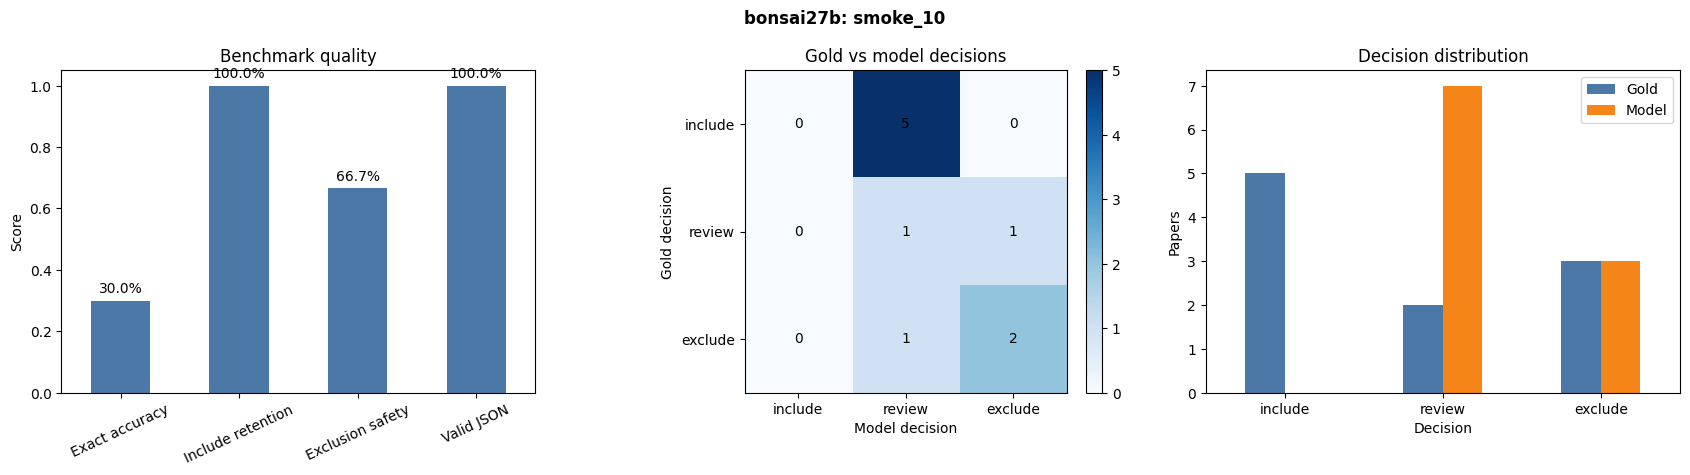

Saved dashboard: /kaggle/working/mufasa_classification/bonsai27b/smoke_10_dashboard.png
Smoke test passed: valid JSON 100%, max prompt tokens 1336, 0.207 papers/s


In [20]:
# Run this first. Inspect the ten predictions before continuing.
smoke_predictions, smoke_metrics = run_benchmark(gold.head(10), "smoke_10")

# A dead backend still produces a full results table, because every failure
# becomes `review`. These gates separate "the model is weak" from
# "nothing ran". Do not run the 200-paper benchmark until they pass.
failures = smoke_predictions.loc[
    ~smoke_predictions["model_valid_json"].astype(bool),
    ["model_error", "model_prompt_tokens", "model_raw_output"],
]
if len(failures):
    display(failures)

assert smoke_metrics["valid_json_rate"] >= 0.8, (
    f"Only {smoke_metrics['valid_json_rate']:.0%} of responses parsed. "
    "The backend is failing, not underperforming — see the rows above."
)
assert smoke_metrics["maximum_reported_prompt_tokens"], (
    "The server reported no prompt tokens, so no request reached the model."
)
assert smoke_metrics["papers_per_second"] < 5, (
    f"{smoke_metrics['papers_per_second']} papers/second is too fast for real "
    "27B generation — requests are being rejected rather than answered."
)
print("Smoke test passed:",
      f"valid JSON {smoke_metrics['valid_json_rate']:.0%},",
      f"max prompt tokens {smoke_metrics['maximum_reported_prompt_tokens']},",
      f"{smoke_metrics['papers_per_second']} papers/s")

Benchmark 200:   0%|          | 0/200 [00:00<?, ?paper/s]

,Model,Papers,Exact accuracy,Include retention,Exclusion safety,Valid JSON,Papers/second,Max input tokens
0,bonsai27b,200,0.525,1.000,0.935,0.990,0.185,1419


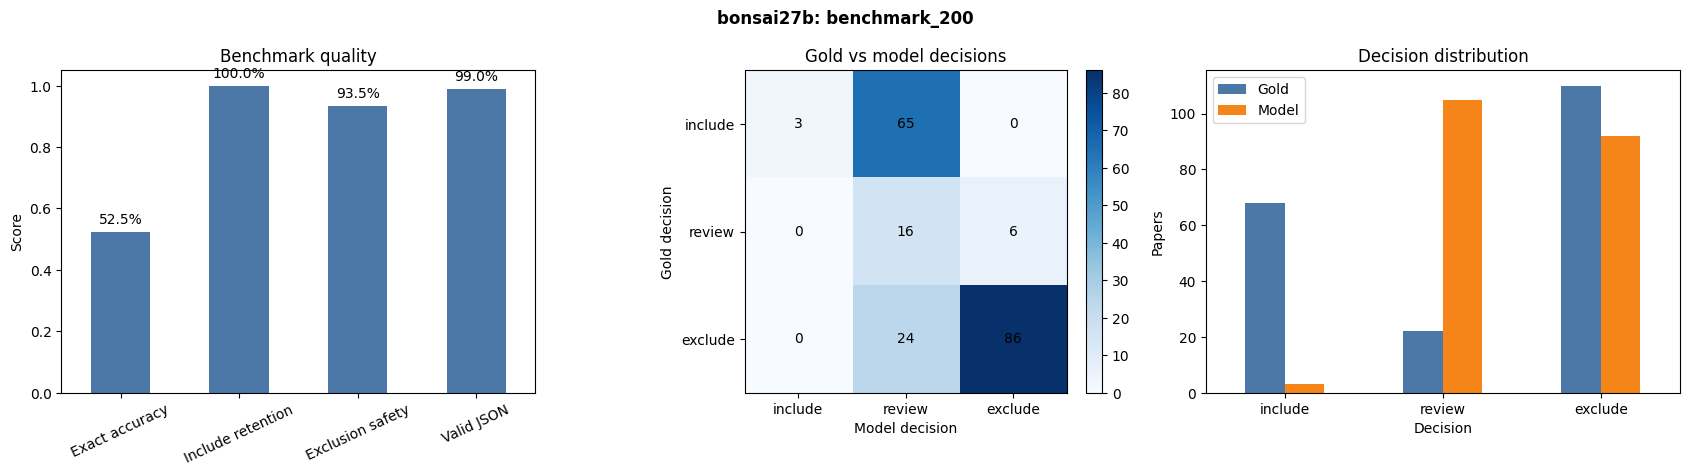

Saved dashboard: /kaggle/working/mufasa_classification/bonsai27b/benchmark_200_dashboard.png


In [21]:
# Run after the smoke test succeeds.
benchmark_predictions, benchmark_results = run_benchmark(gold, "benchmark_200")

### Compare all completed model benchmarks

Rerun this cell after benchmarking each of the three models.


,Model,Exact accuracy,Include retention,Exclusion safety,Valid JSON,Papers/second,Max input tokens
0,qwen2b,0.450,0.971,0.907,0.985,0.489,1419
1,qwen4b,0.345,1.000,0.909,1.000,0.411,1419
2,bonsai27b,0.525,1.000,0.935,0.990,0.185,1419


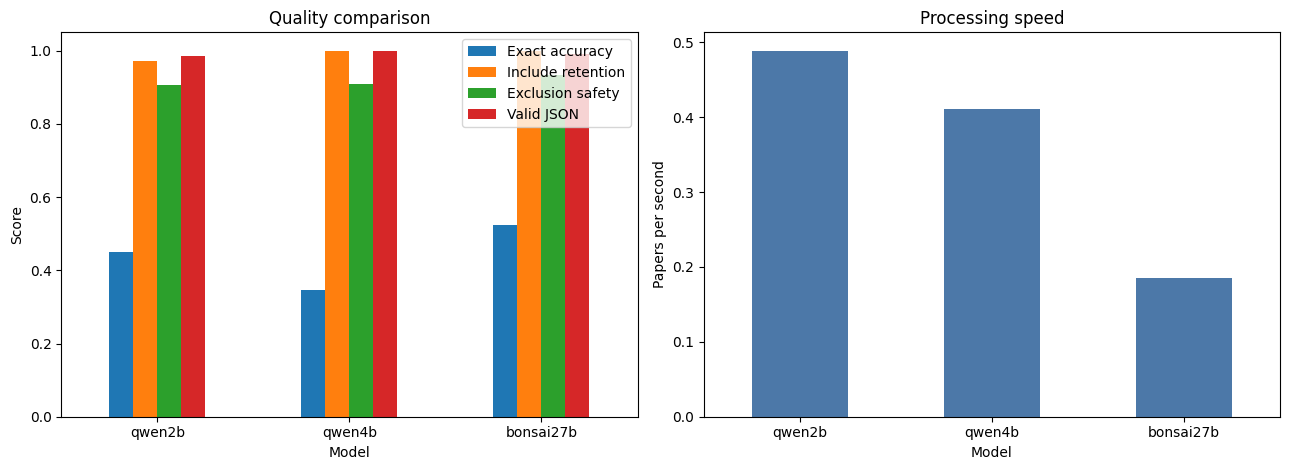

Saved comparison: /kaggle/working/mufasa_classification/benchmark_model_comparison.png


In [22]:
def compare_completed_models() -> pd.DataFrame:
    rows = []
    for choice in MODEL_IDS:
        metrics_path = OUTPUT_ROOT / choice / "benchmark_200_metrics.json"
        if not metrics_path.exists():
            continue
        metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
        rows.append(
            {
                "Model": choice,
                "Exact accuracy": metrics["exact_decision_accuracy"],
                "Include retention": metrics["gold_include_retention"],
                "Exclusion safety": metrics["exclusion_safety"],
                "Valid JSON": metrics["valid_json_rate"],
                "Papers/second": metrics["papers_per_second"],
                "Max input tokens": metrics["maximum_reported_prompt_tokens"],
            }
        )
    comparison = pd.DataFrame(rows)
    if comparison.empty:
        print("No completed 200-paper benchmarks found yet.")
        return comparison

    comparison.to_csv(
        OUTPUT_ROOT / "benchmark_model_comparison.csv",
        index=False,
        encoding="utf-8-sig",
    )
    display(comparison.style.format(precision=3))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    comparison.set_index("Model")[
        ["Exact accuracy", "Include retention", "Exclusion safety", "Valid JSON"]
    ].plot.bar(ax=axes[0], ylim=(0, 1.05), title="Quality comparison")
    axes[0].set_ylabel("Score")
    axes[0].tick_params(axis="x", rotation=0)
    comparison.set_index("Model")["Papers/second"].plot.bar(
        ax=axes[1],
        color="#4C78A8",
        title="Processing speed",
    )
    axes[1].set_ylabel("Papers per second")
    axes[1].tick_params(axis="x", rotation=0)
    fig.tight_layout()
    comparison_plot = OUTPUT_ROOT / "benchmark_model_comparison.png"
    fig.savefig(comparison_plot, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved comparison:", comparison_plot)
    return comparison


model_comparison = compare_completed_models()

## 10. Citation-first production workflow

In [23]:
def validate_candidates(frame: pd.DataFrame) -> None:
    required = set(SLIM_COLUMNS)
    missing = sorted(required - set(frame.columns))
    if missing:
        raise ValueError(f"Missing candidate columns: {missing}")
    if frame["openalex_id"].duplicated().any():
        raise ValueError("openalex_id must be unique")


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    if not path.exists():
        return []
    records = []
    with path.open("r", encoding="utf-8") as handle:
        for line in handle:
            if not line.strip():
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                break
    return records


def append_jsonl(path: Path, records: Iterable[dict[str, Any]]) -> None:
    with path.open("a", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False) + "\n")
        handle.flush()


def write_production_outputs(
    output_dir: Path,
    records: list[dict[str, Any]],
) -> None:
    frame = pd.DataFrame.from_records(records)
    frame.to_parquet(output_dir / "results.parquet", index=False)
    frame.to_csv(
        output_dir / "results.csv",
        index=False,
        encoding="utf-8-sig",
    )
    selected = frame[frame["selected_for_corpus"].astype(bool)].copy()
    selected.to_parquet(output_dir / "selected_papers.parquet", index=False)
    selected.to_csv(
        output_dir / "selected_papers.csv",
        index=False,
        encoding="utf-8-sig",
    )
    summary = {
        "processed": int(len(frame)),
        "selected": int(len(selected)),
        "decision_counts": frame["model_decision"].value_counts().to_dict(),
        "selected_by_field": {
            str(int(key)): int(value)
            for key, value in selected["field_id"].value_counts().items()
        },
        "target_total": TARGET_TOTAL,
        "target_per_field": TARGET_PER_FIELD,
        "updated_at": utc_now(),
    }
    (output_dir / "run_summary.json").write_text(
        json.dumps(summary, indent=2), encoding="utf-8"
    )
    summary_row = dict(summary)
    summary_row["decision_counts"] = json.dumps(
        summary["decision_counts"], ensure_ascii=False
    )
    summary_row["selected_by_field"] = json.dumps(
        summary["selected_by_field"], ensure_ascii=False
    )
    pd.DataFrame([summary_row]).to_csv(
        output_dir / "run_summary.csv",
        index=False,
        encoding="utf-8-sig",
    )


def classify_production_batch(
    batch: pd.DataFrame,
    stage: str,
    selected_by_field: defaultdict[int, int],
    selected_total: int,
):
    outputs = classify_rows([row for _, row in batch.iterrows()])
    records = []
    for (_, row), output in zip(batch.iterrows(), outputs, strict=True):
        field_id = int(row["field_id"])
        selected = False
        if output["model_decision"] == "include":
            if stage == "field_quota":
                selected = selected_by_field[field_id] < TARGET_PER_FIELD
            else:
                selected = selected_total < TARGET_TOTAL
        if selected:
            selected_by_field[field_id] += 1
            selected_total += 1
        records.append(
            row_dict(row)
            | output
            | {
                "selection_stage": stage,
                "selected_for_corpus": selected,
            }
        )
    return records, selected_total


def run_production():
    candidates = ordered_candidates(pd.read_parquet(SLIM_PARQUET))
    validate_candidates(candidates)
    output_dir = MODEL_OUTPUT_DIR / "production"
    output_dir.mkdir(parents=True, exist_ok=True)
    checkpoint = output_dir / "results.jsonl"

    all_records = read_jsonl(checkpoint)
    processed_ids = {str(record["openalex_id"]) for record in all_records}
    if len(processed_ids) != len(all_records):
        raise ValueError("Checkpoint contains duplicate OpenAlex IDs")

    selected_by_field = defaultdict(int)
    for record in all_records:
        if as_bool(record.get("selected_for_corpus")):
            selected_by_field[int(record["field_id"])] += 1
    selected_total = sum(selected_by_field.values())
    since_checkpoint = 0
    progress = tqdm(
        total=TARGET_TOTAL,
        initial=selected_total,
        desc="Selecting papers",
        unit="selected",
    )

    def save(records, stage, field):
        nonlocal since_checkpoint
        append_jsonl(checkpoint, records)
        all_records.extend(records)
        processed_ids.update(str(record["openalex_id"]) for record in records)
        since_checkpoint += len(records)
        if since_checkpoint >= CHECKPOINT_EVERY:
            write_production_outputs(output_dir, all_records)
            since_checkpoint = 0
            tqdm.write(
                f"Checkpoint saved: {len(all_records):,} processed, "
                f"{selected_total:,} selected"
            )
        progress.update(max(0, selected_total - progress.n))
        progress.set_postfix(
            processed=len(all_records),
            field=field,
            stage=stage,
        )

    # First pass: citation-first inside each field until 300 includes.
    for field_id, queue in candidates.groupby("field_id", sort=True):
        field_id = int(field_id)
        if selected_total >= TARGET_TOTAL:
            break
        if selected_by_field[field_id] >= TARGET_PER_FIELD:
            continue
        remaining = queue[
            ~queue["openalex_id"].astype(str).isin(processed_ids)
        ]
        position = 0
        while (
            position < len(remaining)
            and selected_by_field[field_id] < TARGET_PER_FIELD
        ):
            slots_left = TARGET_PER_FIELD - selected_by_field[field_id]
            current_batch_size = min(BATCH_SIZE, slots_left)
            batch = remaining.iloc[position : position + current_batch_size]
            position += len(batch)
            records, selected_total = classify_production_batch(
                batch, "field_quota", selected_by_field, selected_total
            )
            save(records, "field quota", field_id)

    # Carry-over: all unprocessed tails, citations first, until exactly 6,000.
    if selected_total < TARGET_TOTAL:
        remaining = candidates[
            ~candidates["openalex_id"].astype(str).isin(processed_ids)
        ].copy()
        remaining["_sort_date"] = pd.to_datetime(
            remaining["publication_date"], errors="coerce"
        )
        remaining = remaining.sort_values(
            ["cited_by_count", "_sort_date", "openalex_id"],
            ascending=[False, False, True],
            kind="stable",
        ).drop(columns="_sort_date")
        for start in range(0, len(remaining), BATCH_SIZE):
            if selected_total >= TARGET_TOTAL:
                break
            batch = remaining.iloc[start : start + BATCH_SIZE]
            records, selected_total = classify_production_batch(
                batch, "carry_over", selected_by_field, selected_total
            )
            save(records, "carry over", "mixed")

    progress.close()
    write_production_outputs(output_dir, all_records)
    if selected_total < TARGET_TOTAL:
        raise RuntimeError(
            f"Candidate pool exhausted with only {selected_total:,} includes"
        )
    print(f"Complete: exactly {selected_total:,} papers selected")
    return pd.read_parquet(output_dir / "selected_papers.parquet")

## 11. Guarded production cell

Run this only after selecting the winning model. It resumes from its JSONL checkpoint after a Kaggle interruption.

In [24]:
if RUN_PRODUCTION:
    selected_papers = run_production()
else:
    print("Production is disabled. Set RUN_PRODUCTION = True only after benchmarking.")

Production is disabled. Set RUN_PRODUCTION = True only after benchmarking.


## Outputs

Each model gets its own folder under `/kaggle/working/mufasa_classification/`.

- `smoke_10_predictions.parquet` and `.csv`
- `smoke_10_metrics.json` and `.csv`
- `benchmark_200_predictions.parquet` and `.csv`
- `benchmark_200_metrics.json` and `.csv`
- `benchmark_200_dashboard.png`
- `benchmark_model_comparison.csv` and `.png`
- `production/results.jsonl`
- `production/results.parquet` and `.csv`
- `production/selected_papers.parquet` and `.csv`
- `production/run_summary.json` and `.csv`

The production Parquet and CSV files keep the source metadata and appends the `model_*`, checkpoint, and selection columns. MUFASA discipline/category classification is intentionally left for a separate later pass.